# Declaración responsable sobre autoría y uso ético de inteligencia artificial, otros recursos o ayuda externa

Con la entrega de esta tarea, declaro de manera responsable que
es el resultado de mi trabajo intelectual personal y creativo, y que ha sido elaborado de acuerdo con los principios éticos y las normas de integridad vigentes en la comunidad académica y, más
específicamente, en la [Universidad Complutense de Madrid](https://www.ucm.es/file/declaracion-responsable-sobre-autoria-y-uso-%C3%89tico-de-herramientas-de-ia).

Soy, pues, autor del material aquí incluido y, cuando no ha sido así y he tomado el material de
otra fuente, lo he citado o bien he declarado su procedencia de forma clara -incluidas, en su
caso, herramientas de inteligencia artificial-. Las ideas y aportaciones principales incluidas en este trabajo, y que acreditan la adquisición de competencias, son mías y no proceden de otras fuentes o han sido reescritas usando material de otras fuentes.

Antes de entregar esta tarea, asegúrate de que todo funcione como se espera:

1. Reinicia el kernel  
   *(En la barra de menú, selecciona **Kernel → Restart**)*  

2. Ejecuta todas las celdas  
   *(En la barra de menú, selecciona **Cell → Run All**)*  

3. Asegúrate de completar todos los lugares donde aparezca:  
   - `YOUR CODE HERE`  
   - `"YOUR ANSWER HERE"`
     
4. Debes borrar las instrucciones que pone `raise NotImplementedError()`

5. Así como tu **nombre** a continuación:

In [228]:
NOMBRE = "GERARDO FRUCTUOSO VIDAL-ARAGÓN"

## Notas para la entrega

* Se deben rellenar todos los cuadernos sin cambiar el nombre.
* Se debe comprimir la carpeta en un fichero `.zip`, llamado `tarea_final.zip`. **Importante**: por favor, no se entreguen ficheros `.rar`.
* Subir el fichero comprimido al campus virtual.

In [229]:
# En esta casilla pon los import que necesites en este cuaderno.

import testing
# YOUR CODE HERE
import pandas as pd
from datetime import datetime
from doctest import testmod 
import numpy as np
import matplotlib.pyplot as plt

global mes_letra
mes_letra = ['ene','feb','mar','abr','may','jun','jul','ago','sep','oct','nov','dic']

# Si línea da error, debería actualizar a una versión más reciente de Python.
type DataFrame = pd.core.frame.DataFrame


# Operaciones con dataframes

En este apartado, vamos a trabajar con tablas de la librería `pandas`, llamadas `dataframes`.

## Carga del dataframe

La primera operación que necesitamos es cargar el archivo de datos en una tabla, como se ve en el siguiente ejemplo.
Ten en cuenta que las columnas `FX_DATA` y `FECHA_INSCRIPCION` deben contener elementos de tipo fecha.
La fecha en la columna `FX_DATA` no presenta mayo complicación, basta con indicarlo en el parámetro 
`parse_dates` de la función que lee el csv. 

Pero como vimos, el paso a fecha de la columna `FECHA_INSCRIPCION` no funciona en algunos sistemas.
Lo que vamos a hacer es tener dos columnas nuevas llamadas `MES_INSCRIPCION` y `ANYO_INSCRIPCION` (en ese orden) de forma que la primera contenga el mes como una cadena de caracteres y la segunda el día como un entero. 

Un último detalle. Si visualizas el CSV (siguiente casilla), podrás observar que la descripción del distrito tiene un espacio adicional que hay que quitar.

In [230]:
with open('inscritos.csv', encoding='utf-8-sig') as fl:
    for _ in range(5):
        print(fl.readline().strip())

FECHA_INSCRIPCION;GENERO_DESC;DISTRITO_COD;DISTRITO_DESC;EDAD;NACIONALIDAD_DESC;OBJETIVOPROFESIONAL1_COD;OBJETIVOPROFESIONAL1_DESC;OBJETIVOPROFESIONAL2_COD;OBJETIVOPROFESIONAL2_DESC;OBJETIVOPROFESIONAL3_COD;OBJETIVOPROFESIONAL3_DESC;FX_CARGA
"ene-24";"Hombre";10;" LATINA";34;"Español";"5833";"Conserjes de edificios";"5220";"Vendedores en tiendas y almacenes";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"
"ene-20";"Hombre";10;" LATINA";40;"Extracomunitario";"5500";"Cajeros y taquilleros (excepto bancos)";"5220";"Vendedores en tiendas y almacenes";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"
"nov-23";"Hombre";13;" PUENTE DE VALLECAS";24;"Extracomunitario";"3510";"Agentes y representantes comerciales";"5420";"Operadores de telemarketing";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"
"oct-23";"Hombre";17;" VILLAVERDE";19;"Extracomunitario";"9820";"Reponedores";"5220";"Vendedores en tiendas y almacenes";"960

Trying:
    by_month(filter_year(load_dataframe("inscritos_test_sample.csv"),2022))
Expecting:
    [('ene', 11), ('feb', 21), ('mar', 13), ('abr', 16), ('may', 19), ('jun', 24), ('jul', 12), ('ago', 19), ('sep', 25), ('oct', 19), ('nov', 20), ('dic', 18)]
ok
Trying:
    filter_year(load_dataframe("inscritos_test_sample.csv"),2022).count()
Expecting:
    FECHA_INSCRIPCION            217
    GENERO_DESC                  217
    DISTRITO_COD                 217
    DISTRITO_DESC                217
    EDAD                         217
    NACIONALIDAD_DESC            217
    OBJETIVOPROFESIONAL1_COD     190
    OBJETIVOPROFESIONAL1_DESC    190
    OBJETIVOPROFESIONAL2_COD     154
    OBJETIVOPROFESIONAL2_DESC    154
    OBJETIVOPROFESIONAL3_COD     123
    OBJETIVOPROFESIONAL3_DESC    123
    FX_CARGA                     217
    MES_INSCRIPCION              217
    ANYO_INSCRIPCION             217
    dtype: int64
ok
Trying:
    load_dataframe("inscritos_test_sample.csv").dtypes
Expecting:

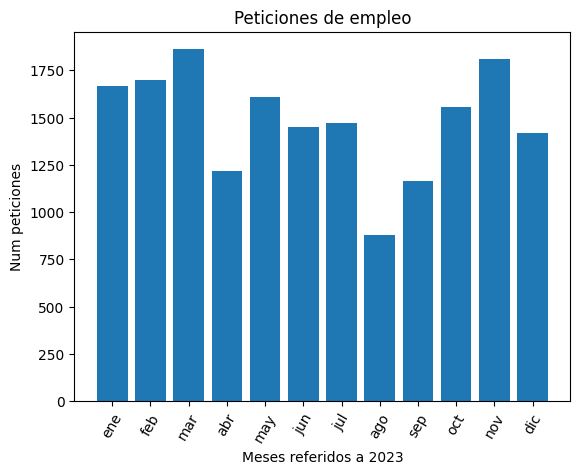

ok
Trying:
    show_district('inscritos.csv', 2022)
Expecting nothing
**********************************************************************
File "__main__", line 12, in gen_sample.show_district
Failed example:
    show_district('inscritos.csv', 2022)
Expected nothing
Got:
    0                     LATINA
    1                     LATINA
    2         PUENTE DE VALLECAS
    3                 VILLAVERDE
    4                 VILLAVERDE
                     ...        
    150132           CARABANCHEL
    150133        OTRO MUNICIPIO
    150134            VILLAVERDE
    150135            ARGANZUELA
    150136           CARABANCHEL
    Name: DISTRITO_DESC, Length: 150137, dtype: str
    9                        RETIRO
    14               OTRO MUNICIPIO
    18           PUENTE DE VALLECAS
    22                  CARABANCHEL
    27                       TETUÁN
                      ...          
    150072    SAN BLAS - CANILLEJAS
    150090                  BARAJAS
    150113       PUENTE

In [267]:
"""
Documentaciones utilizadas:
https://saturncloud.io/blog/how-to-split-one-column-into-multiple-columns-in-pandas-dataframe/#:~:text=Using%20the%20pd.&text=Series.-,str.,list%20as%20a%20new%20column.
https://www.geeksforgeeks.org/pandas/convert-the-column-type-from-string-to-datetime-format-in-pandas-dataframe/
https://pandas.pydata.org/docs/reference/api/pandas.Series.str.lstrip.html
"""
def load_dataframe(archivo: str) -> DataFrame:
    """
    Funcion para cargar un dataframe de pandass a base de un archivo de inscripciones
    Variable de entrada:
        archivo: str -> Nombre del archivo a convertir en df
    
    Variable de salida:
        df: DataFrame -> El dataframe
    
    Test:
    >>> load_dataframe("inscritos_test_sample.csv").dtypes
    FECHA_INSCRIPCION                       str
    GENERO_DESC                             str
    DISTRITO_COD                          int64
    DISTRITO_DESC                           str
    EDAD                                float64
    NACIONALIDAD_DESC                       str
    OBJETIVOPROFESIONAL1_COD            float64
    OBJETIVOPROFESIONAL1_DESC               str
    OBJETIVOPROFESIONAL2_COD            float64
    OBJETIVOPROFESIONAL2_DESC               str
    OBJETIVOPROFESIONAL3_COD            float64
    OBJETIVOPROFESIONAL3_DESC               str
    FX_CARGA                     datetime64[us]
    MES_INSCRIPCION                         str
    ANYO_INSCRIPCION                      int64
    dtype: object
    """
    df = pd.read_csv(archivo, delimiter=';')
    df[['MES_INSCRIPCION','ANYO_INSCRIPCION']] = df['FECHA_INSCRIPCION'].str.split('-',expand=True)
    df['ANYO_INSCRIPCION'] = df['ANYO_INSCRIPCION'].astype('int64')
    df['FX_CARGA'] = pd.to_datetime(df['FX_CARGA'], format="%Y-%m-%d %H:%M:%S.%f")
    df['DISTRITO_DESC'] = df['DISTRITO_DESC'].str.lstrip()
    return df
    # print(df)
    # print(str(df['FX_CARGA'].dtype))
    # print(str(df['ANYO_INSCRIPCION'].dtype))

# str(load_dataframe("inscritos_test_sample.csv")['ANYO_INSCRIPCION'].dtype)

if __name__ == '__main__':
    testmod(name='gen_sample', verbose=True)


In [232]:
# Casilla para hacer pruebas

data = load_dataframe("inscritos_test_sample.csv")
print(str(data['ANYO_INSCRIPCION'].dtype))
print(data.dtypes)


int64
FECHA_INSCRIPCION                       str
GENERO_DESC                             str
DISTRITO_COD                          int64
DISTRITO_DESC                           str
EDAD                                float64
NACIONALIDAD_DESC                       str
OBJETIVOPROFESIONAL1_COD            float64
OBJETIVOPROFESIONAL1_DESC               str
OBJETIVOPROFESIONAL2_COD            float64
OBJETIVOPROFESIONAL2_DESC               str
OBJETIVOPROFESIONAL3_COD            float64
OBJETIVOPROFESIONAL3_DESC               str
FX_CARGA                     datetime64[us]
MES_INSCRIPCION                         str
ANYO_INSCRIPCION                      int64
dtype: object


### Auto-comprobación

In [233]:
# Prueba:

full_data = load_dataframe("inscritos.csv")

print(full_data.dtypes)
full_data

FECHA_INSCRIPCION                       str
GENERO_DESC                             str
DISTRITO_COD                          int64
DISTRITO_DESC                           str
EDAD                                  int64
NACIONALIDAD_DESC                       str
OBJETIVOPROFESIONAL1_COD            float64
OBJETIVOPROFESIONAL1_DESC               str
OBJETIVOPROFESIONAL2_COD            float64
OBJETIVOPROFESIONAL2_DESC               str
OBJETIVOPROFESIONAL3_COD            float64
OBJETIVOPROFESIONAL3_DESC               str
FX_CARGA                     datetime64[us]
MES_INSCRIPCION                         str
ANYO_INSCRIPCION                      int64
dtype: object


,FECHA_INSCRIPCION,GENERO_DESC,DISTRITO_COD,DISTRITO_DESC,EDAD,NACIONALIDAD_DESC,OBJETIVOPROFESIONAL1_COD,OBJETIVOPROFESIONAL1_DESC,OBJETIVOPROFESIONAL2_COD,OBJETIVOPROFESIONAL2_DESC,OBJETIVOPROFESIONAL3_COD,OBJETIVOPROFESIONAL3_DESC,FX_CARGA,MES_INSCRIPCION,ANYO_INSCRIPCION
0,ene-24,Hombre,10,LATINA,34,Español,5833.0,Conserjes de edificios,5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,ene,24
1,ene-20,Hombre,10,LATINA,40,Extracomunitario,5500.0,Cajeros y taquilleros (excepto bancos),5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,ene,20
2,nov-23,Hombre,13,PUENTE DE VALLECAS,24,Extracomunitario,3510.0,Agentes y representantes comerciales,5420.0,Operadores de telemarketing,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,nov,23
3,oct-23,Hombre,17,VILLAVERDE,19,Extracomunitario,9820.0,Reponedores,5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,oct,23
4,may-23,Hombre,17,VILLAVERDE,42,Extracomunitario,9512.0,"Peones agrícolas en huertas, invernaderos, viv...",5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,may,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150132,may-23,Mujer,11,CARABANCHEL,33,Extracomunitario,5500.0,Cajeros y taquilleros (excepto bancos),5420.0,Operadores de telemarketing,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,may,23
150133,mar-19,Mujer,22,OTRO MUNICIPIO,50,Extracomunitario,8193.0,"Operadores de máquinas de embalaje, embotellam...",5220.0,Vendedores en tiendas y almacenes,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,mar,19
150134,may-21,Hombre,17,VILLAVERDE,35,Extracomunitario,8333.0,Operadores de carretillas elevadoras,5942.0,Auxiliares de vigilante de seguridad y similar...,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,may,21
150135,dic-18,Hombre,2,ARGANZUELA,42,Español,9811.0,Peones del transporte de mercancías y descarga...,5942.0,Auxiliares de vigilante de seguridad y similar...,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,dic,18


Salida esperada

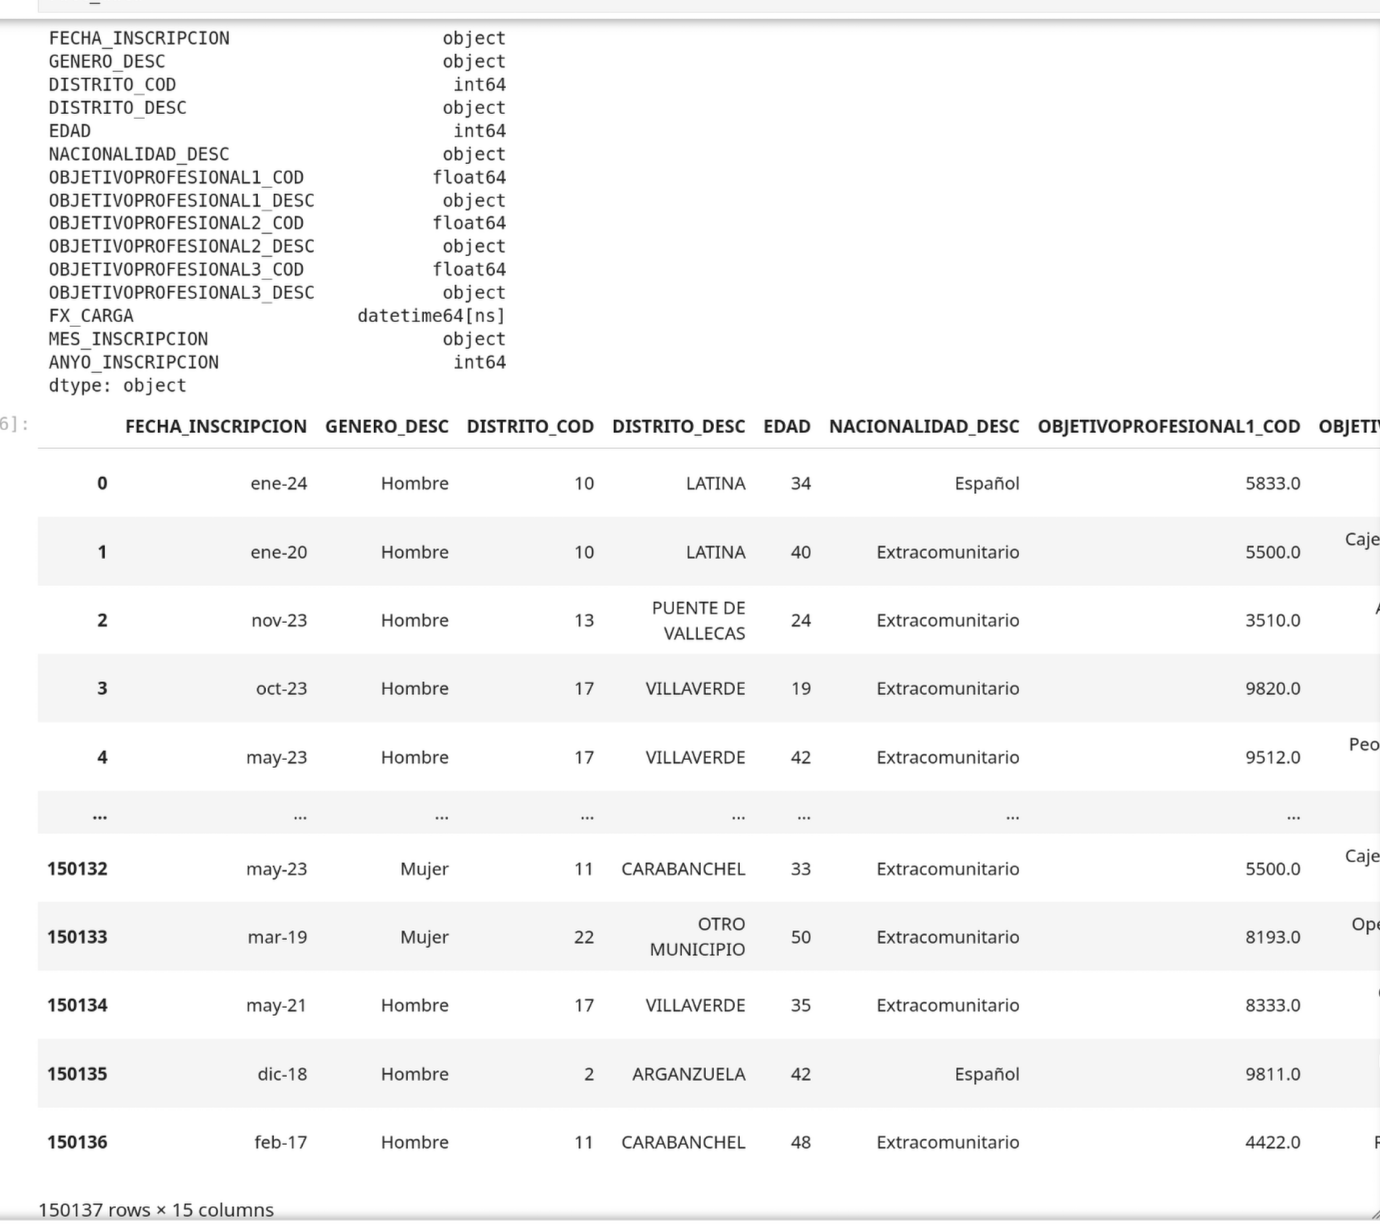

### Comprobaciones automáticas

In [234]:
testing.test_load_dataframe(load_dataframe)
    


size = (150137, 15).....OK
El tipo de la columna FECHA_INSCRIPCION es object....OK
El tipo de la columna GENERO_DESC es object....OK
El tipo de la columna DISTRITO_COD es int64....OK
El tipo de la columna DISTRITO_DESC es object....OK
El tipo de la columna EDAD es int64....OK
El tipo de la columna NACIONALIDAD_DESC es object....OK
El tipo de la columna OBJETIVOPROFESIONAL1_COD es float64....OK
El tipo de la columna OBJETIVOPROFESIONAL1_DESC es object....OK
El tipo de la columna OBJETIVOPROFESIONAL2_COD es float64....OK
El tipo de la columna OBJETIVOPROFESIONAL2_DESC es object....OK
El tipo de la columna OBJETIVOPROFESIONAL3_COD es float64....OK
El tipo de la columna OBJETIVOPROFESIONAL3_DESC es object....OK
El tipo de la columna FX_CARGA es datetime64[ns]....OK
El tipo de la columna MES_INSCRIPCION es object....OK
El tipo de la columna ANYO_INSCRIPCION es int64....OK
OK


In [235]:
testing.test_type_hints_load_dataframe(load_dataframe)

load_dataframe type hints OK


In [236]:
testing.test_docstring(load_dataframe)

docstring OK


In [237]:
testing.test_doctests(load_dataframe, globals())

doctests OK


### Una tabla más reducida

En efecto: no vamos a necesitar las columnas de los objetivos profesionales. Define una función `reduce_cols` que devuelva una tabla reducida con las columnas deseadas.  

Trying:
    by_month(filter_year(load_dataframe("inscritos_test_sample.csv"),2022))
Expecting:
    [('ene', 11), ('feb', 21), ('mar', 13), ('abr', 16), ('may', 19), ('jun', 24), ('jul', 12), ('ago', 19), ('sep', 25), ('oct', 19), ('nov', 20), ('dic', 18)]
ok
Trying:
    filter_year(load_dataframe("inscritos_test_sample.csv"),2022).count()
Expecting:
    FECHA_INSCRIPCION            217
    GENERO_DESC                  217
    DISTRITO_COD                 217
    DISTRITO_DESC                217
    EDAD                         217
    NACIONALIDAD_DESC            217
    OBJETIVOPROFESIONAL1_COD     190
    OBJETIVOPROFESIONAL1_DESC    190
    OBJETIVOPROFESIONAL2_COD     154
    OBJETIVOPROFESIONAL2_DESC    154
    OBJETIVOPROFESIONAL3_COD     123
    OBJETIVOPROFESIONAL3_DESC    123
    FX_CARGA                     217
    MES_INSCRIPCION              217
    ANYO_INSCRIPCION             217
    dtype: int64
ok
Trying:
    load_dataframe("inscritos_test_sample.csv").dtypes
Expecting:

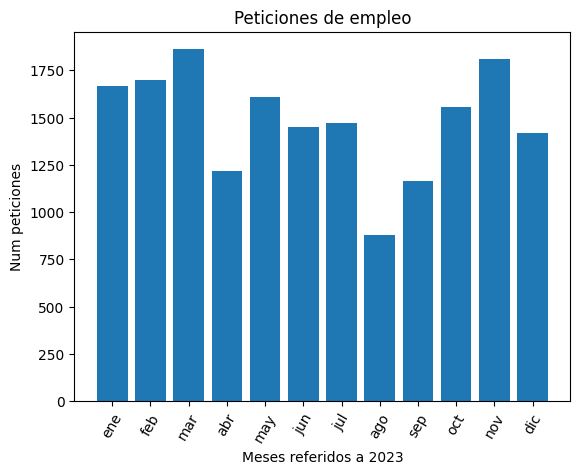

ok
Trying:
    show_district('inscritos.csv', 2022)
Expecting nothing
**********************************************************************
File "__main__", line 12, in reduce_cols.show_district
Failed example:
    show_district('inscritos.csv', 2022)
Expected nothing
Got:
           FECHA_INSCRIPCION GENERO_DESC  DISTRITO_COD       DISTRITO_DESC  EDAD  \
    0                 ene-24      Hombre            10              LATINA    34   
    1                 ene-20      Hombre            10              LATINA    40   
    2                 nov-23      Hombre            13  PUENTE DE VALLECAS    24   
    3                 oct-23      Hombre            17          VILLAVERDE    19   
    4                 may-23      Hombre            17          VILLAVERDE    42   
    ...                  ...         ...           ...                 ...   ...   
    150132            may-23       Mujer            11         CARABANCHEL    33   
    150133            mar-19       Mujer            2

In [238]:

# YOUR CODE HERE
"""
Documentacion utilizada:
https://stackoverflow.com/questions/13411544/delete-a-column-from-a-pandas-dataframe
"""
def reduce_cols(df: DataFrame) -> DataFrame:
    """
    Funcion para eliminar las columnas de objetivo profesional
    Variable de entrada:
        - df: DataFrame -> El data frame al que se le quiera quitar las columnas
    
    Variable de salida:
        - df_no_cols: DataFrame -> El mismo data frame sin estas columnas
    
    Tests:
    >>> reduce_cols(load_dataframe("inscritos_test_sample.csv")).dtypes
    FECHA_INSCRIPCION               str
    GENERO_DESC                     str
    DISTRITO_COD                  int64
    DISTRITO_DESC                   str
    EDAD                        float64
    NACIONALIDAD_DESC               str
    FX_CARGA             datetime64[us]
    MES_INSCRIPCION                 str
    ANYO_INSCRIPCION              int64
    dtype: object
    """
    df_no_cols = df.drop(columns=['OBJETIVOPROFESIONAL1_COD', 'OBJETIVOPROFESIONAL1_DESC','OBJETIVOPROFESIONAL2_COD', 'OBJETIVOPROFESIONAL2_DESC','OBJETIVOPROFESIONAL3_COD', 'OBJETIVOPROFESIONAL3_DESC'])
    return df_no_cols

if __name__ == '__main__':
    testmod(name='reduce_cols', verbose=True)

In [239]:
# Casilla para pruebas

df = load_dataframe("inscritos_test_sample.csv")
print(reduce_cols(df).dtypes)

FECHA_INSCRIPCION               str
GENERO_DESC                     str
DISTRITO_COD                  int64
DISTRITO_DESC                   str
EDAD                        float64
NACIONALIDAD_DESC               str
FX_CARGA             datetime64[us]
MES_INSCRIPCION                 str
ANYO_INSCRIPCION              int64
dtype: object


### Auto-comprobacion

In [240]:
mini = reduce_cols(full_data)
print(mini.dtypes)
mini

FECHA_INSCRIPCION               str
GENERO_DESC                     str
DISTRITO_COD                  int64
DISTRITO_DESC                   str
EDAD                          int64
NACIONALIDAD_DESC               str
FX_CARGA             datetime64[us]
MES_INSCRIPCION                 str
ANYO_INSCRIPCION              int64
dtype: object


,FECHA_INSCRIPCION,GENERO_DESC,DISTRITO_COD,DISTRITO_DESC,EDAD,NACIONALIDAD_DESC,FX_CARGA,MES_INSCRIPCION,ANYO_INSCRIPCION
0,ene-24,Hombre,10,LATINA,34,Español,2025-08-07 00:11:57.897,ene,24
1,ene-20,Hombre,10,LATINA,40,Extracomunitario,2025-08-07 00:11:57.897,ene,20
2,nov-23,Hombre,13,PUENTE DE VALLECAS,24,Extracomunitario,2025-08-07 00:11:57.897,nov,23
3,oct-23,Hombre,17,VILLAVERDE,19,Extracomunitario,2025-08-07 00:11:57.897,oct,23
4,may-23,Hombre,17,VILLAVERDE,42,Extracomunitario,2025-08-07 00:11:57.897,may,23
...,...,...,...,...,...,...,...,...,...
150132,may-23,Mujer,11,CARABANCHEL,33,Extracomunitario,2025-08-07 00:12:50.377,may,23
150133,mar-19,Mujer,22,OTRO MUNICIPIO,50,Extracomunitario,2025-08-07 00:12:50.377,mar,19
150134,may-21,Hombre,17,VILLAVERDE,35,Extracomunitario,2025-08-07 00:12:50.377,may,21
150135,dic-18,Hombre,2,ARGANZUELA,42,Español,2025-08-07 00:12:50.377,dic,18


Salida esperada

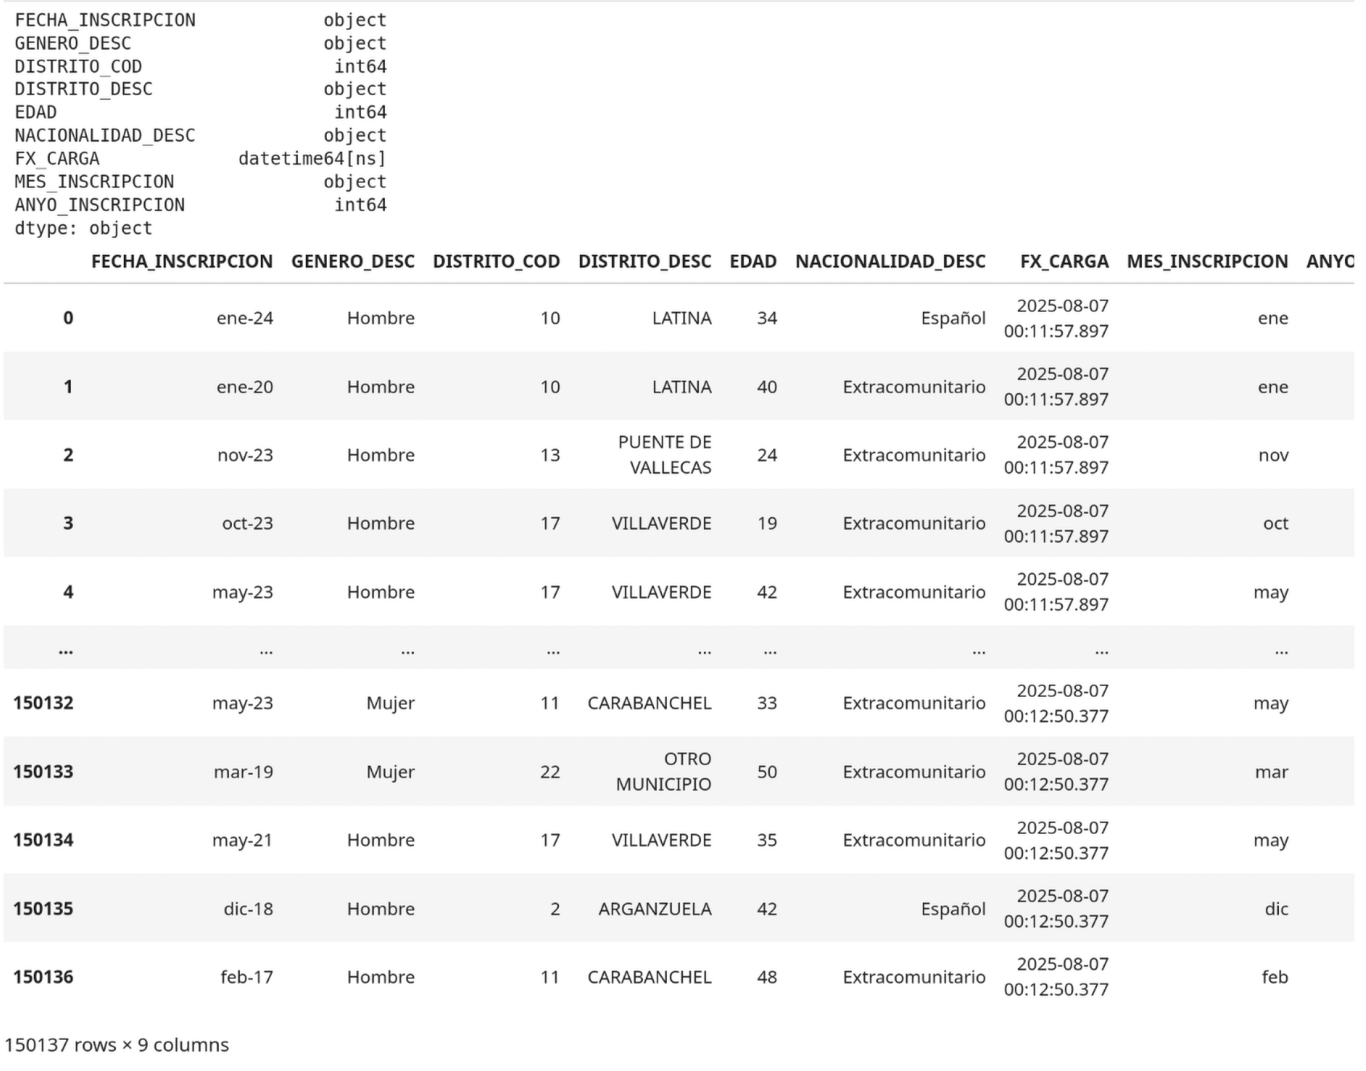

### Comprobaciones automáticas

In [241]:
testing.test_reduce_cols(reduce_cols, load_dataframe)
    

size = (150137, 9).....OK
Columnas...... OK
El tipo de la columna FECHA_INSCRIPCION es object....OK
El tipo de la columna GENERO_DESC es object....OK
El tipo de la columna DISTRITO_COD es int64....OK
El tipo de la columna DISTRITO_DESC es object....OK
El tipo de la columna EDAD es int64....OK
El tipo de la columna NACIONALIDAD_DESC es object....OK
El tipo de la columna FX_CARGA es datetime64[ns]....OK
El tipo de la columna MES_INSCRIPCION es object....OK
El tipo de la columna ANYO_INSCRIPCION es int64....OK


In [242]:
testing.test_type_hints_reduce_cols(reduce_cols)

reduce_cols type hints OK
reduce_cols type hints OK


In [243]:
testing.test_docstring(reduce_cols)

docstring OK


In [244]:
testing.test_doctests(reduce_cols, globals())

doctests OK


### Selección de un año

Define una función `filter_year` que dado un DataFrame nos devuelva las columnas que se correspondan con un determinado año.

Trying:
    by_month(filter_year(load_dataframe("inscritos_test_sample.csv"),2022))
Expecting:
    [('ene', 11), ('feb', 21), ('mar', 13), ('abr', 16), ('may', 19), ('jun', 24), ('jul', 12), ('ago', 19), ('sep', 25), ('oct', 19), ('nov', 20), ('dic', 18)]
ok
Trying:
    filter_year(load_dataframe("inscritos_test_sample.csv"),2022).count()
Expecting:
    FECHA_INSCRIPCION            217
    GENERO_DESC                  217
    DISTRITO_COD                 217
    DISTRITO_DESC                217
    EDAD                         217
    NACIONALIDAD_DESC            217
    OBJETIVOPROFESIONAL1_COD     190
    OBJETIVOPROFESIONAL1_DESC    190
    OBJETIVOPROFESIONAL2_COD     154
    OBJETIVOPROFESIONAL2_DESC    154
    OBJETIVOPROFESIONAL3_COD     123
    OBJETIVOPROFESIONAL3_DESC    123
    FX_CARGA                     217
    MES_INSCRIPCION              217
    ANYO_INSCRIPCION             217
    dtype: int64
ok
Trying:
    load_dataframe("inscritos_test_sample.csv").dtypes
Expecting:

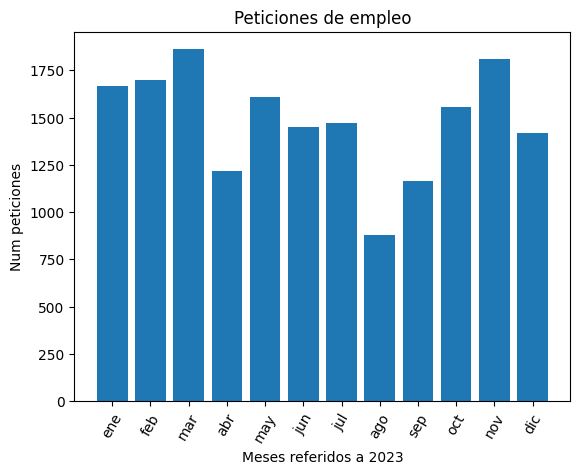

ok
Trying:
    show_district('inscritos.csv', 2022)
Expecting nothing
**********************************************************************
File "__main__", line 12, in filter_year.show_district
Failed example:
    show_district('inscritos.csv', 2022)
Expected nothing
Got:
           FECHA_INSCRIPCION GENERO_DESC  DISTRITO_COD       DISTRITO_DESC  EDAD  \
    0                 ene-24      Hombre            10              LATINA    34   
    1                 ene-20      Hombre            10              LATINA    40   
    2                 nov-23      Hombre            13  PUENTE DE VALLECAS    24   
    3                 oct-23      Hombre            17          VILLAVERDE    19   
    4                 may-23      Hombre            17          VILLAVERDE    42   
    ...                  ...         ...           ...                 ...   ...   
    150132            may-23       Mujer            11         CARABANCHEL    33   
    150133            mar-19       Mujer            2

In [245]:
# YOUR CODE HERE
"""
Documentacion utilizada:
https://www.geeksforgeeks.org/pandas/ways-to-filter-pandas-dataframe-by-column-values/
"""
def filter_year(df: DataFrame, year: int) -> DataFrame:
    """
    Funcion para hacer un filtro por año. Importante! Tener en cuenta que tiene que ser año 2000 + x donde x es el año de la inscripcion
    Por ejempplo(si es en 2024, en los datos viene 24, por eso se le suma 2000)
    Variable de entrada:
        - df: DataFrame -> Los dfatos que se quieran filtrar
        - year: int -> El año por el que se quiere filtrar
    
    Variable de salida:
        - filtered_df: DataFrame -> El dataframe filtrado
    
    Tests:
    >>> filter_year(load_dataframe("inscritos_test_sample.csv"),2022).count()
    FECHA_INSCRIPCION            217
    GENERO_DESC                  217
    DISTRITO_COD                 217
    DISTRITO_DESC                217
    EDAD                         217
    NACIONALIDAD_DESC            217
    OBJETIVOPROFESIONAL1_COD     190
    OBJETIVOPROFESIONAL1_DESC    190
    OBJETIVOPROFESIONAL2_COD     154
    OBJETIVOPROFESIONAL2_DESC    154
    OBJETIVOPROFESIONAL3_COD     123
    OBJETIVOPROFESIONAL3_DESC    123
    FX_CARGA                     217
    MES_INSCRIPCION              217
    ANYO_INSCRIPCION             217
    dtype: int64
    """
    filtered_df = df[df['ANYO_INSCRIPCION']+2000 == year]
    return filtered_df

if __name__ == '__main__':
    testmod(name='filter_year', verbose=True)

In [246]:
# Casilla para hacer pruebas
df = load_dataframe("inscritos_test_sample.csv")

df2 = filter_year(df,2022)
print(df2.count())

FECHA_INSCRIPCION            217
GENERO_DESC                  217
DISTRITO_COD                 217
DISTRITO_DESC                217
EDAD                         217
NACIONALIDAD_DESC            217
OBJETIVOPROFESIONAL1_COD     190
OBJETIVOPROFESIONAL1_DESC    190
OBJETIVOPROFESIONAL2_COD     154
OBJETIVOPROFESIONAL2_DESC    154
OBJETIVOPROFESIONAL3_COD     123
OBJETIVOPROFESIONAL3_DESC    123
FX_CARGA                     217
MES_INSCRIPCION              217
ANYO_INSCRIPCION             217
dtype: int64


### Auto-comprobación

In [247]:
year_2022 = filter_year(mini, 2022)
year_2022

,FECHA_INSCRIPCION,GENERO_DESC,DISTRITO_COD,DISTRITO_DESC,EDAD,NACIONALIDAD_DESC,FX_CARGA,MES_INSCRIPCION,ANYO_INSCRIPCION
9,ago-22,Hombre,3,RETIRO,57,Extracomunitario,2025-08-07 00:11:57.897,ago,22
14,jun-22,Hombre,22,OTRO MUNICIPIO,21,Extracomunitario,2025-08-07 00:11:57.897,jun,22
18,feb-22,Hombre,13,PUENTE DE VALLECAS,47,Español,2025-08-07 00:11:57.897,feb,22
22,ago-22,Mujer,11,CARABANCHEL,27,Español,2025-08-07 00:11:57.897,ago,22
27,jul-22,Hombre,6,TETUÁN,35,Extracomunitario,2025-08-07 00:11:57.897,jul,22
...,...,...,...,...,...,...,...,...,...
150072,dic-22,Mujer,20,SAN BLAS - CANILLEJAS,38,Español,2025-08-07 00:12:50.377,dic,22
150090,sep-22,Hombre,21,BARAJAS,20,Extracomunitario,2025-08-07 00:12:50.377,sep,22
150113,abr-22,Hombre,13,PUENTE DE VALLECAS,25,Extracomunitario,2025-08-07 00:12:50.377,abr,22
150121,mar-22,Hombre,10,LATINA,25,Comunitario,2025-08-07 00:12:50.377,mar,22


Salida esperada

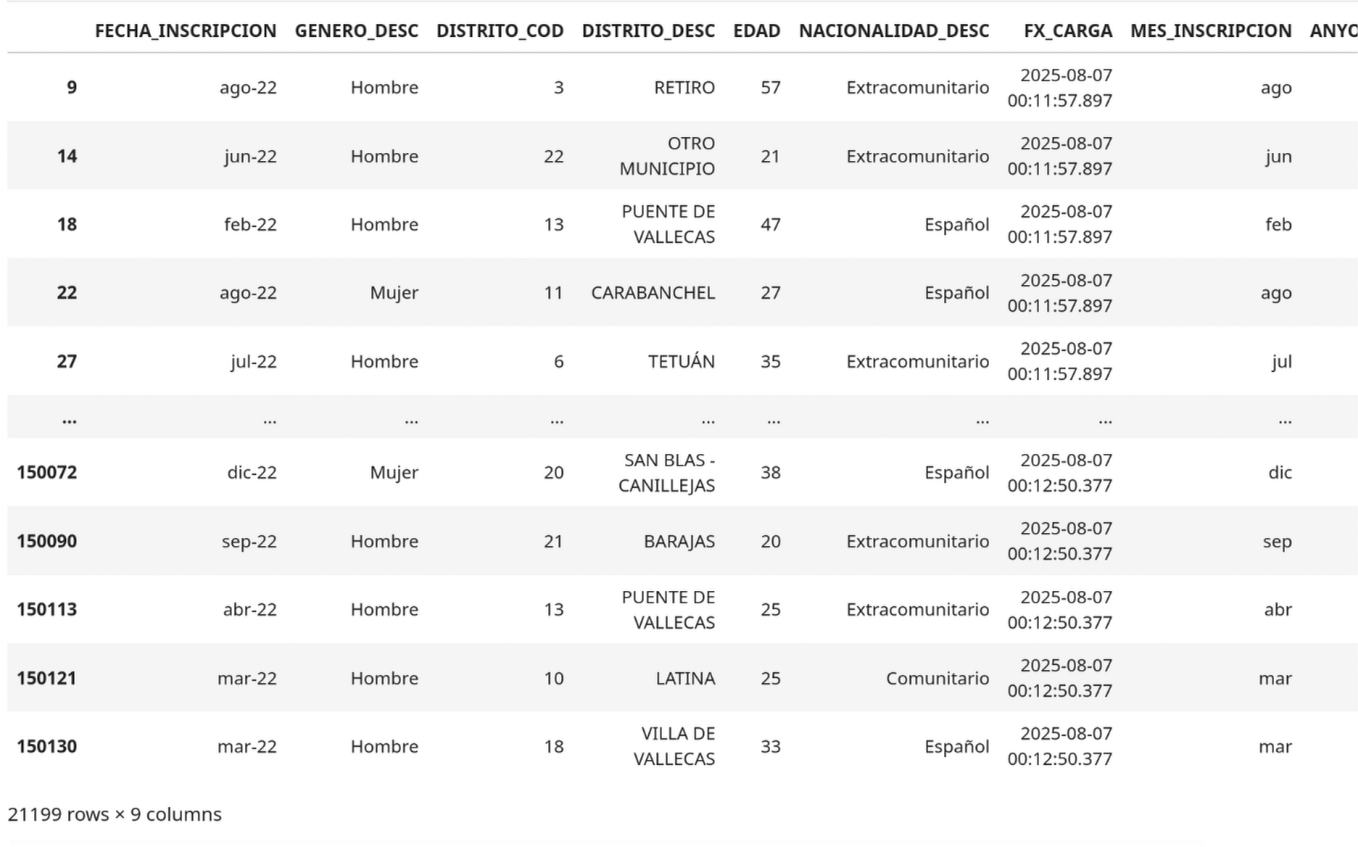

### Comprobaciones automáticas

In [248]:
testing.test_filter_year(filter_year, load_dataframe)



OK


In [249]:
testing.test_type_hints_filter_year(filter_year)

filter_year type hints OK
filter_year type hints OK


In [250]:
testing.test_docstring(filter_year)

docstring OK


In [251]:
testing.test_doctests(filter_year, globals())

doctests OK


## Tanteo por meses

Realiza una función `by_month` que dado el DataFrame de un año,  obtenga una lista ordenada de tuplas de la forma `(mes, total)` tal que el total es el número de personas que se han inscrito en ese mes. La función deberá hacer un agrupamiento en el DataFrame y transformar el resultado para que finalmente devuelva algo del tipo `list[tuple[str, int]]`. La lista deberá estar ordenada con respecto al mes.

Trying:
    by_month(filter_year(load_dataframe("inscritos_test_sample.csv"),2022))
Expecting:
    [('ene', 11), ('feb', 21), ('mar', 13), ('abr', 16), ('may', 19), ('jun', 24), ('jul', 12), ('ago', 19), ('sep', 25), ('oct', 19), ('nov', 20), ('dic', 18)]
ok
Trying:
    filter_year(load_dataframe("inscritos_test_sample.csv"),2022).count()
Expecting:
    FECHA_INSCRIPCION            217
    GENERO_DESC                  217
    DISTRITO_COD                 217
    DISTRITO_DESC                217
    EDAD                         217
    NACIONALIDAD_DESC            217
    OBJETIVOPROFESIONAL1_COD     190
    OBJETIVOPROFESIONAL1_DESC    190
    OBJETIVOPROFESIONAL2_COD     154
    OBJETIVOPROFESIONAL2_DESC    154
    OBJETIVOPROFESIONAL3_COD     123
    OBJETIVOPROFESIONAL3_DESC    123
    FX_CARGA                     217
    MES_INSCRIPCION              217
    ANYO_INSCRIPCION             217
    dtype: int64
ok
Trying:
    load_dataframe("inscritos_test_sample.csv").dtypes
Expecting:

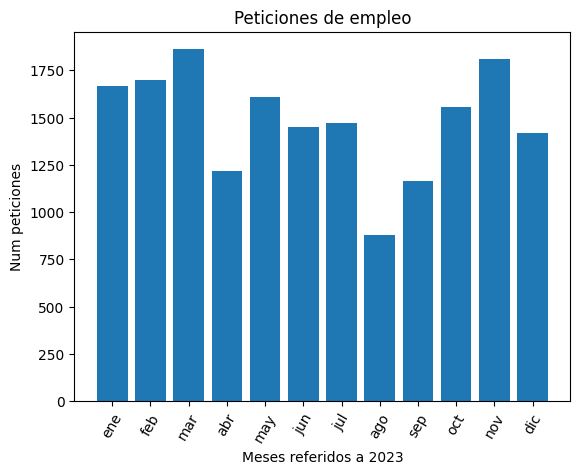

ok
Trying:
    show_district('inscritos.csv', 2022)
Expecting nothing
**********************************************************************
File "__main__", line 12, in by_month.show_district
Failed example:
    show_district('inscritos.csv', 2022)
Expected nothing
Got:
           FECHA_INSCRIPCION GENERO_DESC  DISTRITO_COD       DISTRITO_DESC  EDAD  \
    0                 ene-24      Hombre            10              LATINA    34   
    1                 ene-20      Hombre            10              LATINA    40   
    2                 nov-23      Hombre            13  PUENTE DE VALLECAS    24   
    3                 oct-23      Hombre            17          VILLAVERDE    19   
    4                 may-23      Hombre            17          VILLAVERDE    42   
    ...                  ...         ...           ...                 ...   ...   
    150132            may-23       Mujer            11         CARABANCHEL    33   
    150133            mar-19       Mujer            22  

In [252]:
"""
Documentacion utilizada: 
https://medium.com/@shouke.wei/easy-methods-of-converting-pandas-dataframe-into-lists-713f3dbd1811
https://www.geeksforgeeks.org/python/python-merge-two-lists-into-list-of-tuples/
Seguramente se pueda hhacer de una mejor forma, pero no la encontré, con lo que la hice un poco mas simple
"""
# YOUR CODE HERE
def by_month(df: DataFrame) -> list[tuple[str,int]]:
    """
    Funcion para que dado un dataframe de un año especifico devuelva una lista de tuplas donde venga indicado el mes con la cantidad total de inscripciones
    variable de entrada:
        df: DataFrame -> Donde vienen los datos del año
    variable de salida:
        final_arr: list[tuple[str,int]] -> Donde viene la cantidad de inscripciones por mes
    Tests:
    >>> by_month(filter_year(load_dataframe("inscritos_test_sample.csv"),2022))
    [('ene', 11), ('feb', 21), ('mar', 13), ('abr', 16), ('may', 19), ('jun', 24), ('jul', 12), ('ago', 19), ('sep', 25), ('oct', 19), ('nov', 20), ('dic', 18)]
    """
    mes_list = df['MES_INSCRIPCION'].to_list()
    counts = [0,0,0,0,0,0,0,0,0,0,0,0]
    for el in mes_list:
        index = mes_letra.index(el)
        counts[index] = counts[index] + 1

    final_arr = list(zip(mes_letra,counts))
    return final_arr

if __name__ == '__main__':
    testmod(name='by_month', verbose=True)


In [253]:
# Casilla para hacer pruebas
by_month(df2)

[('ene', 11),
 ('feb', 21),
 ('mar', 13),
 ('abr', 16),
 ('may', 19),
 ('jun', 24),
 ('jul', 12),
 ('ago', 19),
 ('sep', 25),
 ('oct', 19),
 ('nov', 20),
 ('dic', 18)]

### Auto-comprobación

In [254]:
bym = by_month(year_2022)
bym

[('ene', 804),
 ('feb', 2129),
 ('mar', 2257),
 ('abr', 1677),
 ('may', 2014),
 ('jun', 1727),
 ('jul', 1338),
 ('ago', 1511),
 ('sep', 1711),
 ('oct', 1939),
 ('nov', 2292),
 ('dic', 1800)]

Salida esperada

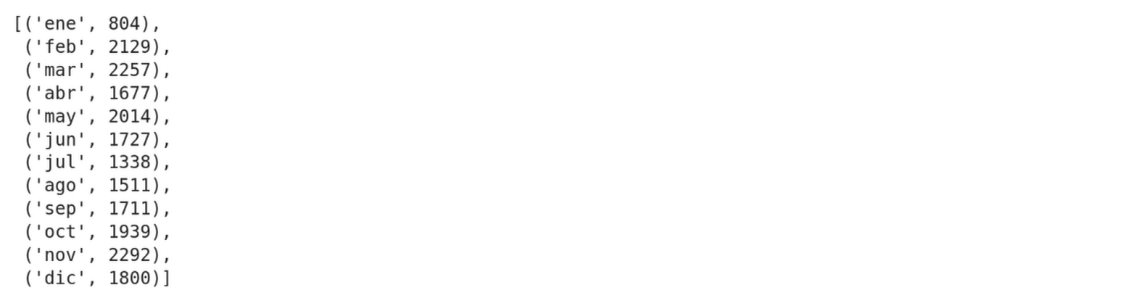

### Comprobaciones automáticas

In [255]:
testing.test_by_month(by_month, filter_year, load_dataframe)

OK


In [256]:
testing.test_type_hints_by_month(by_month)

by_month type hints OK


In [257]:
testing.test_docstring(by_month)

docstring OK


In [258]:
testing.test_doctests(by_month, globals())


doctests OK


# Gráficas

Finalmente, vamos a realizar un par de gráficos. En primer lugar, queremos sacar el número de personas inscritas por cada mes. Realiza una función `show_by_month` que reciba como dato de entrada un fichero de datos csv y un año y que  realice gráfico de barras del número de desempleados por meses de ese año


Trying:
    by_month(filter_year(load_dataframe("inscritos_test_sample.csv"),2022))
Expecting:
    [('ene', 11), ('feb', 21), ('mar', 13), ('abr', 16), ('may', 19), ('jun', 24), ('jul', 12), ('ago', 19), ('sep', 25), ('oct', 19), ('nov', 20), ('dic', 18)]
ok
Trying:
    filter_year(load_dataframe("inscritos_test_sample.csv"),2022).count()
Expecting:
    FECHA_INSCRIPCION            217
    GENERO_DESC                  217
    DISTRITO_COD                 217
    DISTRITO_DESC                217
    EDAD                         217
    NACIONALIDAD_DESC            217
    OBJETIVOPROFESIONAL1_COD     190
    OBJETIVOPROFESIONAL1_DESC    190
    OBJETIVOPROFESIONAL2_COD     154
    OBJETIVOPROFESIONAL2_DESC    154
    OBJETIVOPROFESIONAL3_COD     123
    OBJETIVOPROFESIONAL3_DESC    123
    FX_CARGA                     217
    MES_INSCRIPCION              217
    ANYO_INSCRIPCION             217
    dtype: int64
ok
Trying:
    load_dataframe("inscritos_test_sample.csv").dtypes
Expecting:

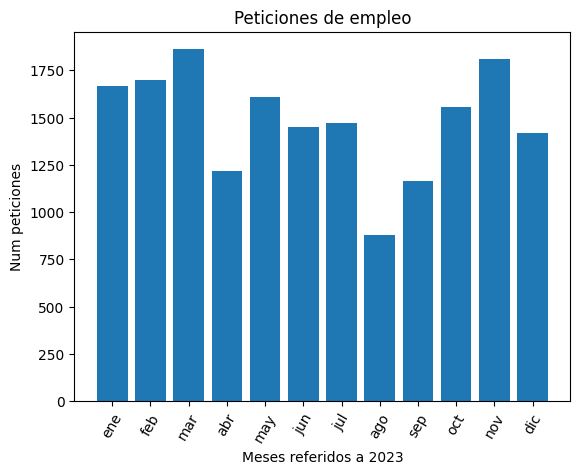

ok
Trying:
    show_district('inscritos.csv', 2022)
Expecting nothing
**********************************************************************
File "__main__", line 12, in show_by_month.show_district
Failed example:
    show_district('inscritos.csv', 2022)
Expected nothing
Got:
           FECHA_INSCRIPCION GENERO_DESC  DISTRITO_COD       DISTRITO_DESC  EDAD  \
    0                 ene-24      Hombre            10              LATINA    34   
    1                 ene-20      Hombre            10              LATINA    40   
    2                 nov-23      Hombre            13  PUENTE DE VALLECAS    24   
    3                 oct-23      Hombre            17          VILLAVERDE    19   
    4                 may-23      Hombre            17          VILLAVERDE    42   
    ...                  ...         ...           ...                 ...   ...   
    150132            may-23       Mujer            11         CARABANCHEL    33   
    150133            mar-19       Mujer           

In [259]:
# YOUR CODE HERE
"""
Documentacion utlizada:
https://stackoverflow.com/questions/42612318/build-a-bar-chart-from-a-list-of-tuples-python
https://stackoverflow.com/questions/42223587/how-to-add-title-and-xlabel-and-ylabel
"""
def show_by_month(archivo: str, year:int) -> None:
    """
    Funcion para que con un archivo y un año, devuelva una grafica de barras donde se vean las peticiones por meses
    Variables de entrada:
        - Archivo: str -> Donde vienen los datos
        - Year: int -> El año que se queire representar
    
    Variables de salida:
        None
    Test:
    >>> show_by_month('inscritos.csv', 2023)
    """

    df = load_dataframe(archivo)
    df_reduced = reduce_cols(df)
    df_filtered = filter_year(df_reduced,year)
    bm = by_month(df_filtered)

    #ahora las graficas

    plt.bar(range(len(bm)), [val[1] for val in bm], align='center')
    plt.xticks(range(len(bm)), [val[0] for val in bm])
    xlabel = 'Meses referidos a ' + str(year)
    plt.xticks(rotation=60)
    plt.xlabel(xlabel)
    plt.ylabel('Num peticiones')
    plt.title('Peticiones de empleo')
    plt.show()
    return None

if __name__ == '__main__':
    testmod(name='show_by_month', verbose=True)

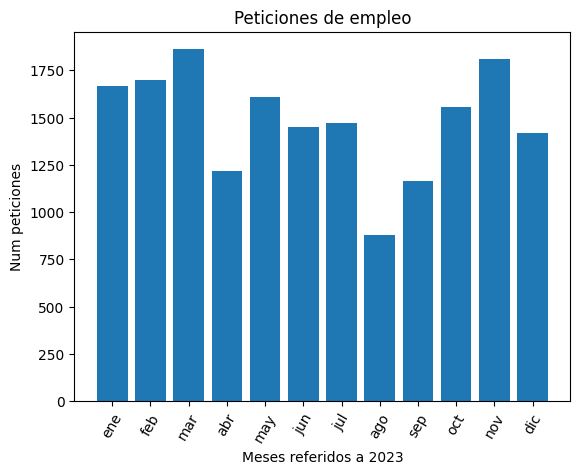

In [260]:
# Casilla para pruebas
show_by_month('inscritos.csv', 2023)

### Auto-comprobación

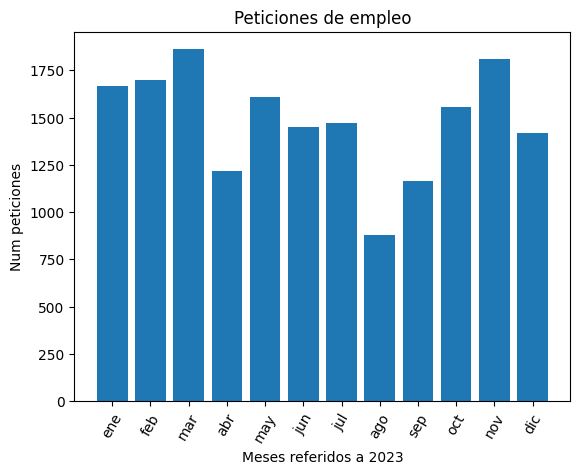

In [261]:
show_by_month('inscritos.csv', 2023)

Salida esperada

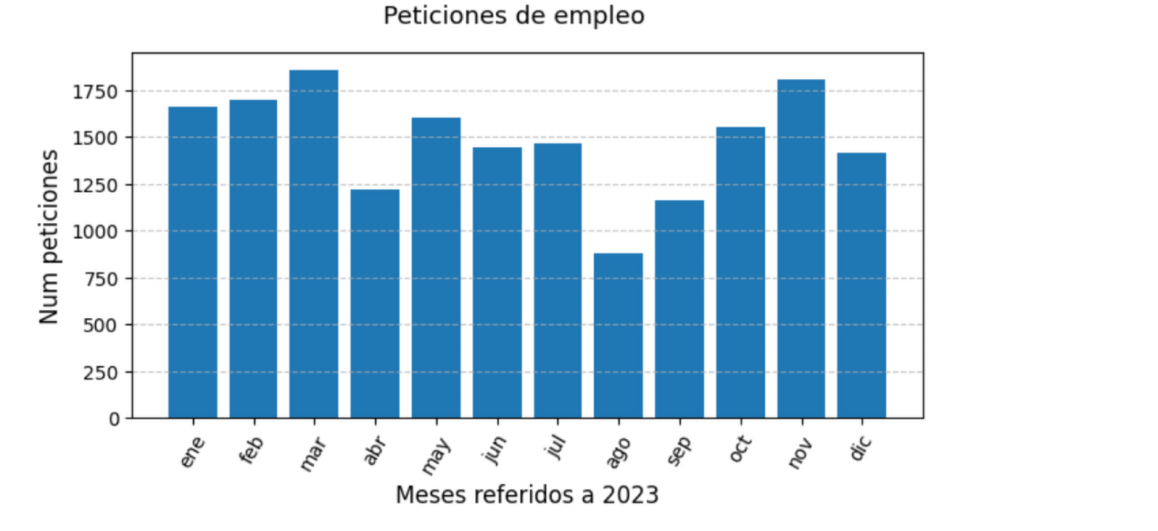

## Inscritos por distritos en un año

Realiza una función `show_district` que genere un gráfico de tarta del número de desempleados por distrito en un determinado año. Al igual que en el caso anterior,
la función recibe como parámetros el nombre de un fichero con los datos y el año. Si lo haces verás que el distrito que más se repite es 'OTRO MUNICIPIO'. Debes filtrar los datos, de forma
que solo se consideren los distritos de Madrid.

In [311]:

# YOUR CODE HERE
"""
Documentaciones utilizadas:
https://pandas.pydata.org/docs/reference/api/pandas.Series.to_list.html
https://stackoverflow.com/questions/50558458/get-frequency-of-item-occurrences-in-a-column-as-percentage
https://www.geeksforgeeks.org/python/plot-a-pie-chart-in-python-using-matplotlib/
https://stackoverflow.com/questions/32925173/store-an-array-of-percentage-values-from-a-for-loop-to-create-a-pie-chart
"""
def show_district(archivo: str, year:int) -> None:
    """
    Funcion para crear un pie chart con los datos de los municipios con su porcentaje de inscripciones
    Variables de entrada:
        - Archivo: str -> Donde vienen los datos
        - Year: int -> El año que se queire representar
    
    Variables de salida:
        None
    Tests:
    >>> show_district('inscritos.csv', 2022)
    """

    df = load_dataframe(archivo)
    
    df_reduced = reduce_cols(df)
    # print(df_reduced['DISTRITO_DESC'])
    df_filtered = filter_year(df_reduced,year)
    # print(df_filtered['DISTRITO_DESC'])
    df_filter_municipio = df_filtered[df_filtered['DISTRITO_DESC'].str.contains('OTRO MUNICIPIO') == False ]
    # print(df_filter_municipio['DISTRITO_DESC'])

    test = df_filter_municipio['DISTRITO_DESC'].value_counts(normalize=True) * 100
    # print(test.to_list())
    # print(test.index.to_list())

    distritos = test.index.to_list()
    porcentajes = test.to_list()


    fig, ax = plt.subplots(figsize=(10, 7))
    plt.pie(porcentajes,labels=distritos, autopct='%1.1f%%')
    ##Investigar poner explode 
    plt.title('Peticiones de empleo por distritos')
    xlabel = 'Datos referidos a ' + str(year)
    plt.xlabel(xlabel)
    plt.show()
    return None

# if __name__ == '__main__':
#     testmod(name='show_by_month', verbose=True)

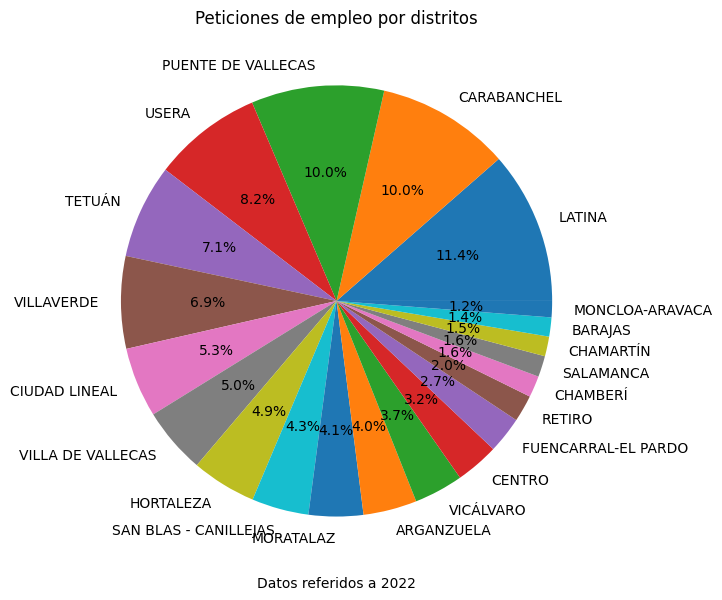

In [310]:
# Casilla para pruebas
show_district('inscritos.csv', 2022)


In [264]:
show_district('inscritos.csv', 2022)

,FECHA_INSCRIPCION,GENERO_DESC,DISTRITO_COD,DISTRITO_DESC,EDAD,NACIONALIDAD_DESC,OBJETIVOPROFESIONAL1_COD,OBJETIVOPROFESIONAL1_DESC,OBJETIVOPROFESIONAL2_COD,OBJETIVOPROFESIONAL2_DESC,OBJETIVOPROFESIONAL3_COD,OBJETIVOPROFESIONAL3_DESC,FX_CARGA,MES_INSCRIPCION,ANYO_INSCRIPCION
0,ene-24,Hombre,10,LATINA,34,Español,5833.0,Conserjes de edificios,5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,ene,24
1,ene-20,Hombre,10,LATINA,40,Extracomunitario,5500.0,Cajeros y taquilleros (excepto bancos),5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,ene,20
2,nov-23,Hombre,13,PUENTE DE VALLECAS,24,Extracomunitario,3510.0,Agentes y representantes comerciales,5420.0,Operadores de telemarketing,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,nov,23
3,oct-23,Hombre,17,VILLAVERDE,19,Extracomunitario,9820.0,Reponedores,5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,oct,23
4,may-23,Hombre,17,VILLAVERDE,42,Extracomunitario,9512.0,"Peones agrícolas en huertas, invernaderos, viv...",5220.0,Vendedores en tiendas y almacenes,9602.0,Peones de la construcción de edificios,2025-08-07 00:11:57.897,may,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150132,may-23,Mujer,11,CARABANCHEL,33,Extracomunitario,5500.0,Cajeros y taquilleros (excepto bancos),5420.0,Operadores de telemarketing,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,may,23
150133,mar-19,Mujer,22,OTRO MUNICIPIO,50,Extracomunitario,8193.0,"Operadores de máquinas de embalaje, embotellam...",5220.0,Vendedores en tiendas y almacenes,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,mar,19
150134,may-21,Hombre,17,VILLAVERDE,35,Extracomunitario,8333.0,Operadores de carretillas elevadoras,5942.0,Auxiliares de vigilante de seguridad y similar...,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,may,21
150135,dic-18,Hombre,2,ARGANZUELA,42,Español,9811.0,Peones del transporte de mercancías y descarga...,5942.0,Auxiliares de vigilante de seguridad y similar...,9811.0,Peones del transporte de mercancías y descarga...,2025-08-07 00:12:50.377,dic,18


Salida esperada

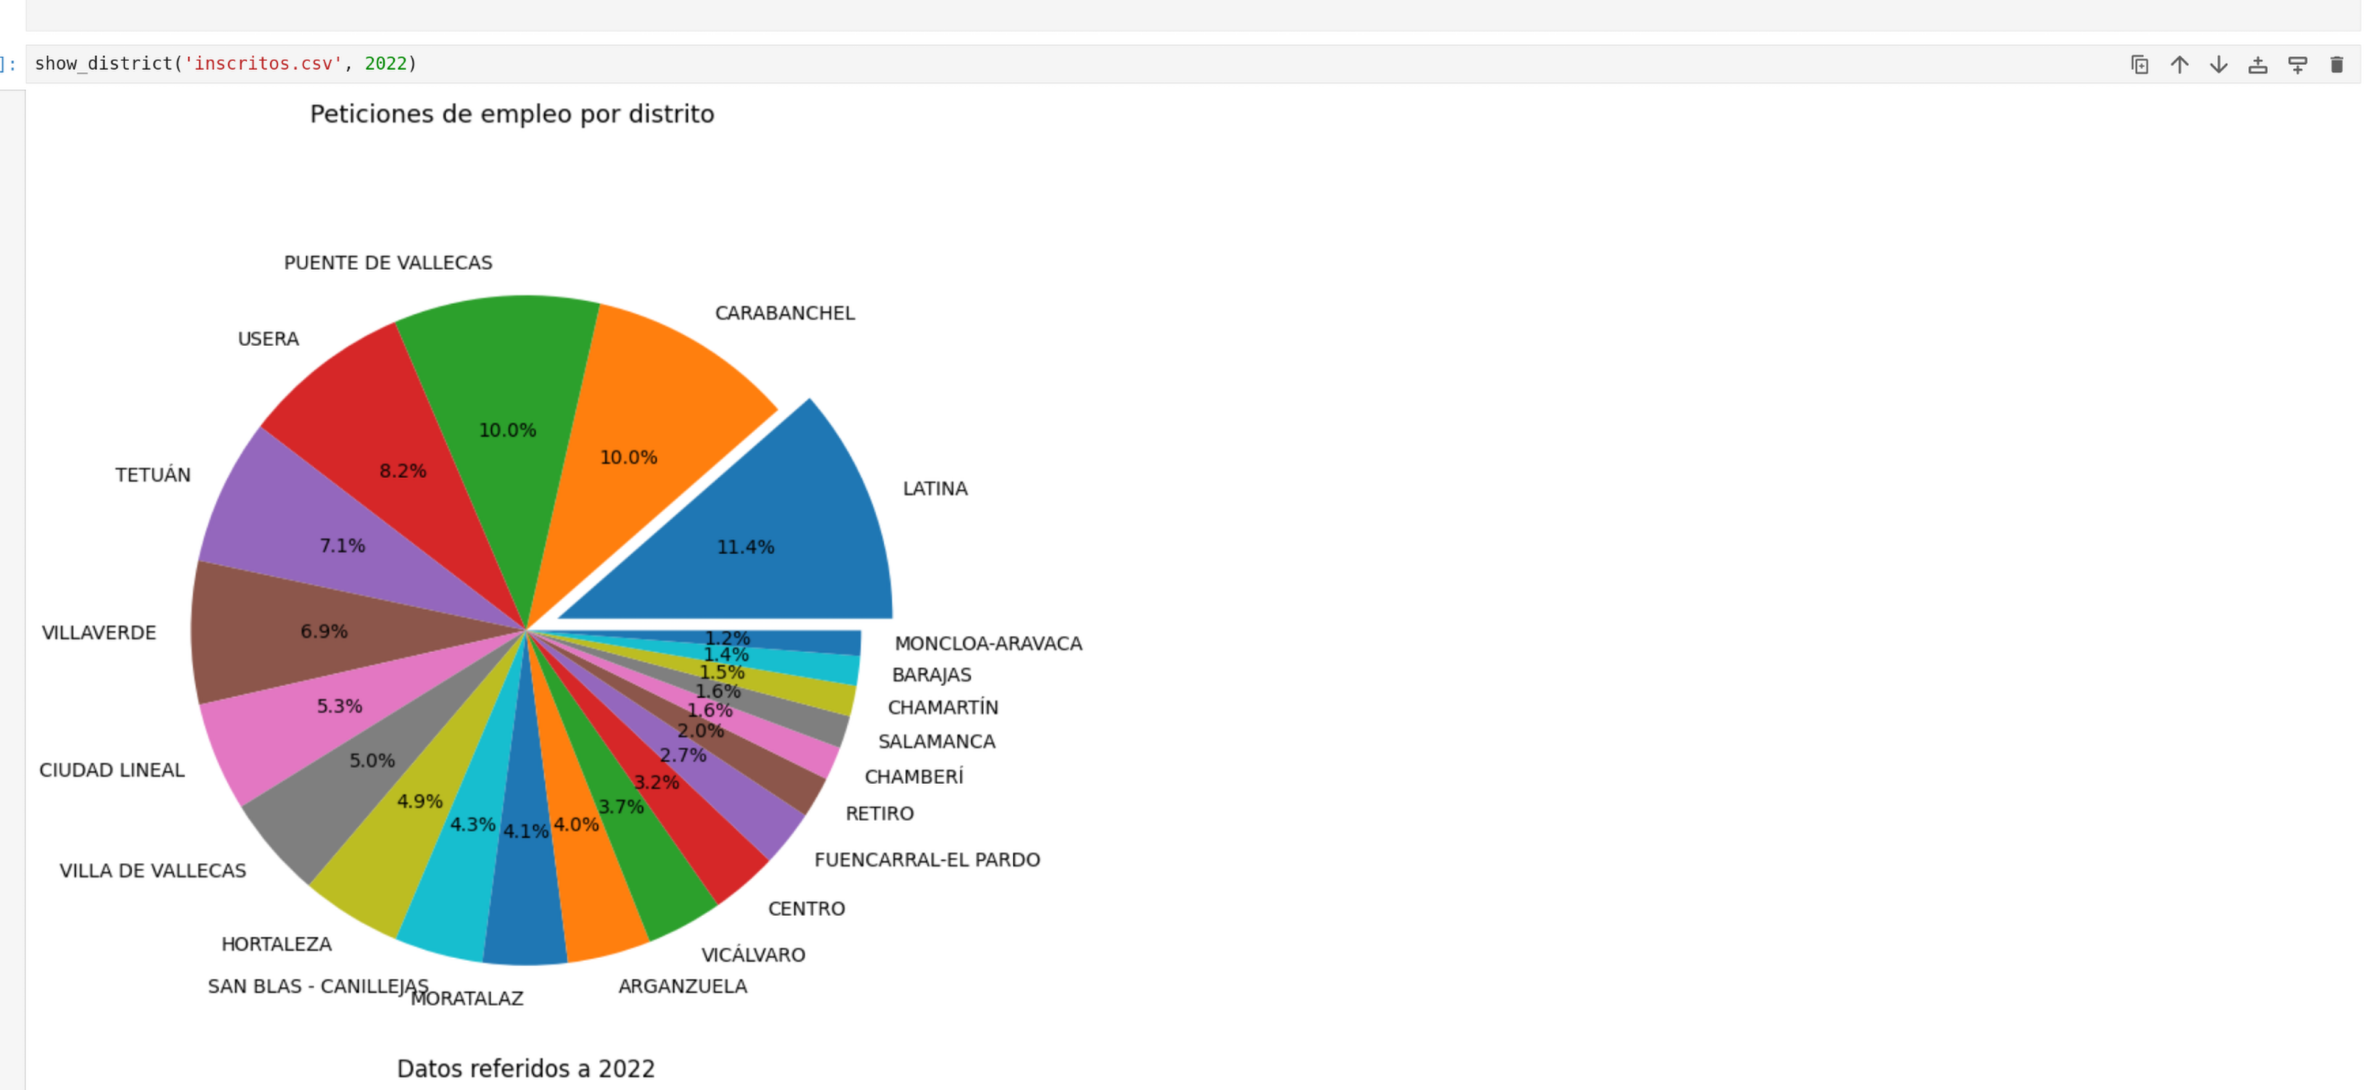